In [1]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 경로 설정
import os 
import sys

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12,6)

# 시드 설정
np.random.seed(42)

print('-' * 60)
print('라이브러리 로드 완료')
print('한글 폰트 설정 완료!')
print('-'* 60)

------------------------------------------------------------
라이브러리 로드 완료
한글 폰트 설정 완료!
------------------------------------------------------------


In [2]:
os.chdir(os.path.abspath('..'))
print(os.getcwd())

df = pd.read_csv('data/df_cleaned.csv')
df.head()

c:\workspace\camp\project\airbnb_price_prediction


,id,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_verifications_email,host_verifications_phone,host_verifications_work_email,log_price,log_estimated_revenue_l365d,amenities_list,has_self_checkin,has_wifi,has_kitchen,has_dryer,has_air_conditioning,has_heating,has_dedicated_workspace,has_hair_dryer,has_iron,has_gym,has_bbq_grill,has_breakfast,has_fireplace,has_smoking_allowed,has_pets_allowed,has_wine_glasses,has_crib,has_city_skyline_view,has_river_view,has_luggage_dropoff_allowed,has_long_term_stays_allowed,has_private_entrance,has_exterior_security_cameras,has_elevator,has_lock_on_bedroom_door,has_tub,has_washer,has_pool,has_alarm,has_garden_courtyard_view,has_outdoor,has_free_parking,amenities_count,count_appliances_expensive,has_ott
0,36121,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,Full of tree-lined streets and beautiful brown...,62165,Michael,2009-12-11,"New York, NY",I’m an urban planner working for an internatio...,NaN,NaN,NaN,False,Prospect Heights,1.0,3.0,True,True,Neighborhood highlights,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",200.0,90,365,90.0,90.0,365.0,365.0,90.0,365.0,True,27,57,87,362,9,0,0,301,0,0,0.0,2010-12-11,2013-05-10,4.88,5.00,4.80,5.00,5.00,5.00,5.00,NaN,False,1,0,1,0,0.05,1,1,1,5.303305,0.000000,"['refrigerator', 'dishes and silverware', 'wif...",0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,7,1,0
1,36647,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,"Manhattan, SE corner of 2nd Ave/ E. 110th street",157798,Irene,2010-07-04,"New York, NY",NaN,NaN,NaN,1.00,False,East Harlem,1.0,1.0,True,True,Neighborhood highlights,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1 private bath,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",82.0,30,999,30.0,30.0,999.0,999.0,30.0,999.0,True,0,0,0,204,102,0,0,143,0,0,0.0,2010-10-04,2023-12-09,4.77,4.82,4.76,4.88,4.90,4.38,4.71,NaN,False,1,0,1,0,0.58,1,1,0,4.418841,0.000000,"['oven', 'blender', 'luggage dropoff allowed',...",0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1,0,0,0,0,0,1,32,5,0
2,38663,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...","diverse, lively, hip, cool: loaded with restau...",165789,Sarah,2010-07-13,"New York, NY",I am a lawyer and work as an executive at an a...,within a few hours,1.0,0.40,False,Boerum Hill,1.0,3.0,True,True,Neighborhood highlights,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,2.5,2.5 baths,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",765.0,3,60,3.0,3.0,60.

0. 제거 행

- 현재 운영되지 않는다고 생각되는 숙소는 제거

In [3]:
base_date = pd.to_datetime('2025-03-02')
host_since = pd.to_datetime(df['host_since'])
df['host_experience_months'] = (base_date.year - host_since.dt.year) * 12 + (base_date.month - host_since.dt.month)

In [4]:
# 리뷰가 없고, 신규 호스트가 아니며 1년 전후로 운영이 되고 있지 않은 곳
cond1 = (df['number_of_reviews'] == 0) & (df['host_experience_months'] > 12)
cond2 = (df['availability_30'] == 30) & (df['availability_60'] == 60) & (df['availability_90'] == 90) & (df['availability_365'] == 365) & (df['estimated_occupancy_l365d'] == 0)
df = df.loc[~(cond1 | cond2)]
len(df)

14804

In [5]:
22308 - 14804

7504

- 위치 좌표가 같고 가격이 같은 곳이 있으면, 머신러닝 모델이 특정 정보를 더 중요하게 생각할 수 있기에, 한 개만 남기고 중복 정보 제거

In [9]:
df[df.duplicated(subset = ['longitude','latitude','name','log_price'])][['id','name','accommodates','bathrooms','room_type','price']]

,id,name,accommodates,bathrooms,room_type,price
161,253466,Loft Suite,4,1.0,Entire home/apt,246.0
162,253471,Loft Suite,4,1.0,Entire home/apt,246.0
163,253475,Loft Suite,4,1.0,Entire home/apt,246.0
164,253800,Loft Suite,4,1.0,Entire home/apt,246.0
174,253803,Loft Suite,4,1.0,Entire home/apt,246.0
175,253806,Loft Suite,4,1.0,Entire home/apt,246.0
176,253811,Loft Suite,4,1.0,Entire home/apt,246.0
188,84010,Superior @ Box House,2,1.0,Hotel room,184.0
198,294242,Loft Suite,4,1.0,Entire home/apt,246.0
199,294259,Loft Suite,4,1.0,Entire home/apt,246.0


In [6]:
group_cols = ['longitude','latitude','name','log_price']

remaining_cols = [c for c in df.columns if c not in group_cols]

def get_mode(x):
    m = x.mode()
    return m.iloc[0] if len(m) > 0 else None

agg_dict = {}

for col in remaining_cols:
    if df[col].dtype in ['float64', 'int64']:
        agg_dict[col] = 'median'
    else:
        agg_dict[col] = get_mode

df_temp = df.copy()
df_temp = df_temp.groupby(group_cols).agg(agg_dict).reset_index()

In [7]:
df = df_temp.loc[:,df.columns]

In [8]:
from shapely.geometry import Point
import geopandas as gpd

# EPSG:32118(뉴욕 기준 미터 단위)로 변환
geo_temp = gpd.GeoDataFrame(df[['id','log_price','estimated_occupancy_l365d']], 
                            geometry = gpd.points_from_xy(df['longitude'], df['latitude']))
geo_temp.set_crs(epsg = 4326, inplace = True)
geo_temp = geo_temp.to_crs(epsg = 32118)

geo_temp.set_index('id')
points = geo_temp[['geometry','estimated_occupancy_l365d']].copy()

for dist in [500,1000]:
    buffers = points.copy()
    buffers['geometry'] = points.geometry.buffer(dist)

    # sjoin (처음 써봐서 1시간 걸림 with gemini)
    # predicate => intersects 서로 겹치면 / within 완전히 안에 포함되면 / contains	포함하고 있으면 / touches 경계가 닿으면 / crosses 교차하면
    joined = gpd.sjoin(buffers, points, how = 'left', predicate = 'contains')
    counts = joined.groupby(level = 0).size() - 1
    total_sums = joined.groupby(level = 0)['estimated_occupancy_l365d_right'].sum()
    # 자기자신의 occupancy는 제외
    occupancy_sums = total_sums - geo_temp['estimated_occupancy_l365d']

    # 2. 결과 저장
    geo_temp[f'competition_count_{dist}m'] = counts.values
    geo_temp[f'occupancy_sum_{dist}m'] = occupancy_sums.values

new_features = [col for col in geo_temp.columns if 'm' in col]

In [9]:
geo_temp[['log_price','competition_count_500m','competition_count_1000m','occupancy_sum_500m','occupancy_sum_1000m']].corr()

,log_price,competition_count_500m,competition_count_1000m,occupancy_sum_500m,occupancy_sum_1000m
log_price,1.000000,0.230251,0.283291,0.212943,0.271151
competition_count_500m,0.230251,1.000000,0.906946,0.980703,0.890078
competition_count_1000m,0.283291,0.906946,1.000000,0.881326,0.991023
occupancy_sum_500m,0.212943,0.980703,0.881326,1.000000,0.880977
occupancy_sum_1000m,0.271151,0.890078,0.991023,0.880977,1.000000


In [10]:
from scipy.stats import pearsonr

print('단순 상관계수')
print(pearsonr(geo_temp['competition_count_1000m'], df['log_price']))

print('log 변환 후 상관계수')
print(pearsonr(np.log1p(geo_temp['competition_count_1000m']), df['log_price']))

단순 상관계수
PearsonRResult(statistic=np.float64(0.2832909358038053), pvalue=np.float64(6.836928677674462e-271))
log 변환 후 상관계수
PearsonRResult(statistic=np.float64(0.28062260535849987), pvalue=np.float64(1.2190770311215556e-265))


<Axes: xlabel='competition_count_1000m', ylabel='Count'>

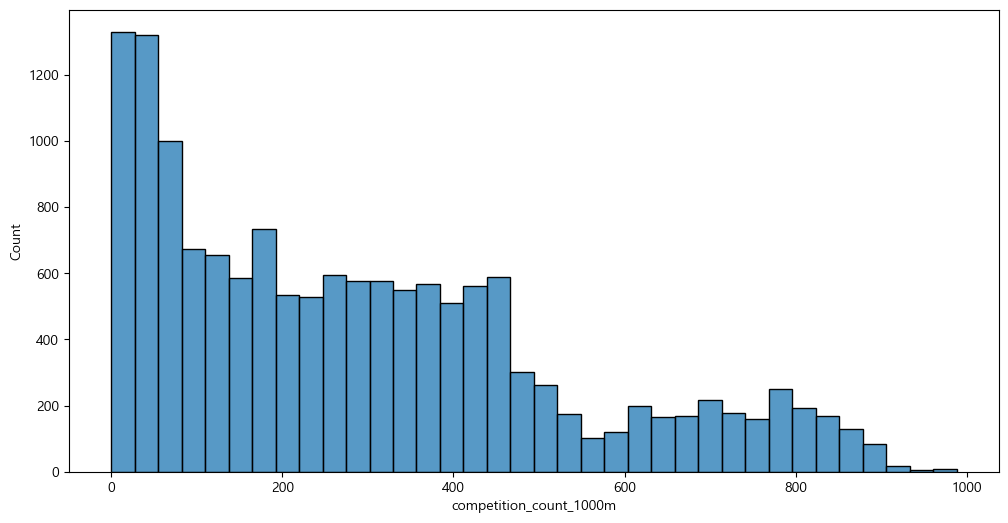

In [11]:
sns.histplot(geo_temp['competition_count_1000m'])

Text(0.5, 0, 'log_competition_count_1000m')

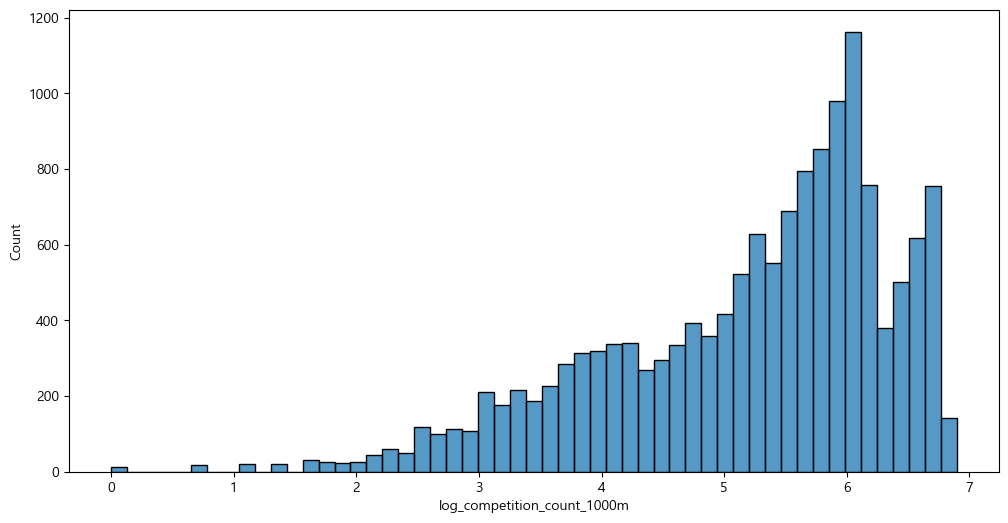

In [12]:
sns.histplot(np.log1p(geo_temp['competition_count_1000m']))
plt.xlabel('log_competition_count_1000m')

In [20]:
tmp = geo_temp['competition_count_500m'] / geo_temp['competition_count_1000m']
tmp = tmp.fillna(0)
pearsonr(tmp, df['log_price'])

PearsonRResult(statistic=np.float64(-0.04022229436239369), pvalue=np.float64(9.972837422266521e-07))

In [21]:
geo_temp['log_competition_count_1000m'] = np.log1p(geo_temp['competition_count_1000m'])

geo_temp['inner_500_devided_1000'] = geo_temp['competition_count_500m'] / geo_temp['competition_count_1000m']
geo_temp['inner_500_devided_1000'] = geo_temp['inner_500_devided_1000'].fillna(0)
geo_final = geo_temp[['id','log_competition_count_1000m','inner_500_devided_1000']]
df = df.merge(geo_final, on = 'id', how = 'inner')

<Axes: xlabel='log_competition_count_1000m', ylabel='log_price'>

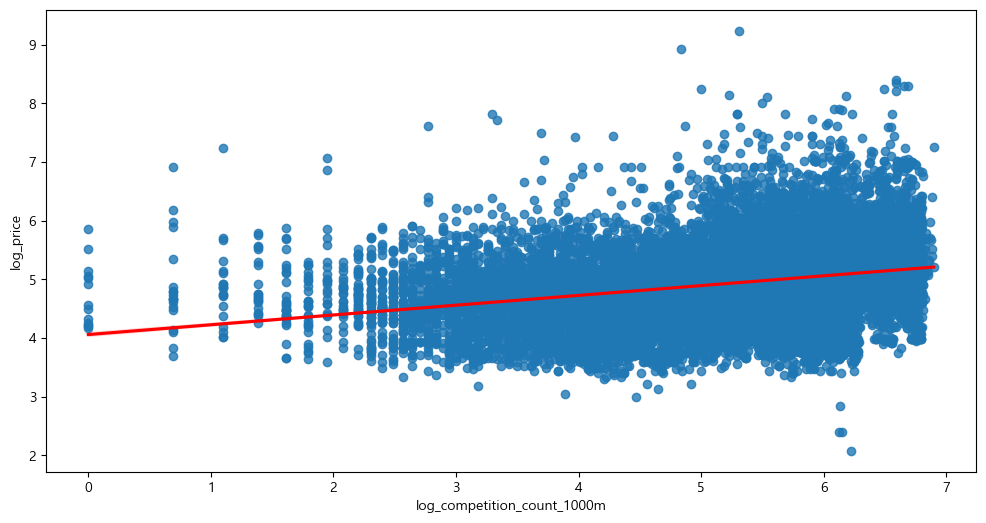

In [26]:
sns.regplot(data = df, x = 'log_competition_count_1000m', y = 'log_price', line_kws={"color": "red"})

<Axes: xlabel='inner_500_devided_1000', ylabel='log_price'>

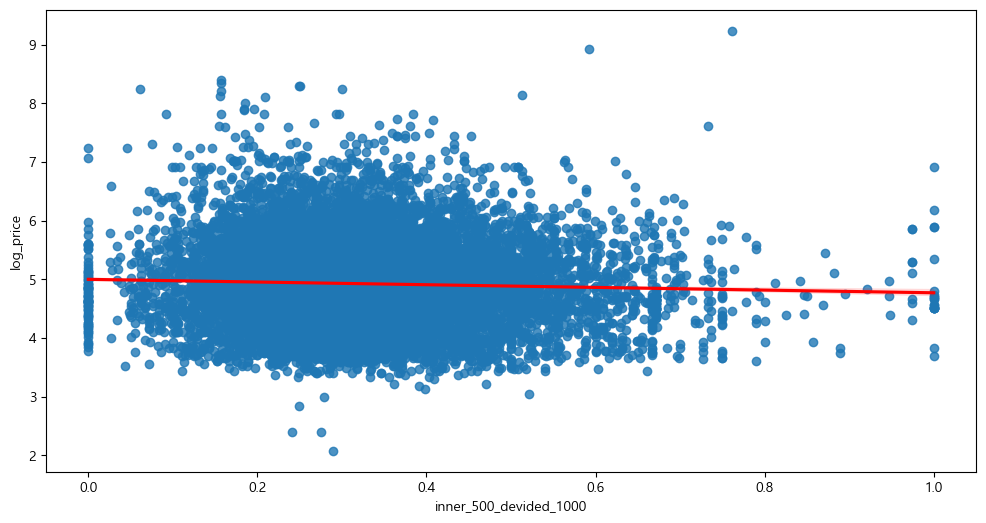

In [27]:
sns.regplot(data = df, x = 'inner_500_devided_1000', y = 'log_price', line_kws={"color": "red"})

1. 제거 변수

- 회의를 통해 의미 없는 변수 제거

In [12]:
drop_cols = ['name', 'neighborhood_overview','host_id','host_name',
            'host_since','host_neighbourhood',
            # 'host_identity_verified',
            'minimum_nights','maximum_nights','minimum_nights_avg_ntm',
            'maximum_nights_avg_ntm','has_availability','reviews_per_month',
            'number_of_reviews_ly','estimated_revenue_l365d','amenities',
            'bathrooms_text','amenities_list', 'log_estimated_revenue_l365d']

df = df.drop(columns = drop_cols)

2. 이진 범주 처리

In [13]:
columns = ['description', 'host_about', 'neighbourhood',
        'license','instant_bookable']

for col in columns:
        df[col] = df[col].map(lambda x: 0 if pd.isna(x) else 1)

3. 서열형 변수 인코딩

In [14]:
response_map = {
    'within an hour': 1,
    'within a few hours': 2,
    'within a day': 3,
    'a few days or more': 4
}

# 결측치 0 처리
df['host_response_time'] = df['host_response_time'].map(response_map).fillna(0)

4. 파생 변수

In [15]:
def convert_host_location(df):
    location_list = []

    parts = df['host_location'].str.split(', ')

    for i, loc in enumerate(parts):
        # 결측치 처리
        if not isinstance(loc, list):
            value = np.nan
        else:
            last_loc = loc[-1].strip()
        
            # 뉴욕
            if last_loc == 'NY' or 'New York' in loc:
                value = 1
            # 그 외 미국 내부
            elif len(last_loc) == 2:
                value = 2
            # 'United States'
            elif last_loc == 'United States':
                if 'New York' in loc[0]:
                    value = 1
                else:
                    value = 2
            else:
                value = 3
                
        location_list.append(value)
    return location_list

host_loc = convert_host_location(df)
df['host_location'] = host_loc

In [16]:
# 대형
def classify_host_size(count):
    if count == 1:
        return 0
    elif 2 <= count <= 10:
        return 1  
    elif count >= 11:
        return 2  
    else:
        return 0 # 결측치 먼저 처리

# 변수 적용
df['host_category'] = df['calculated_host_listings_count'].apply(classify_host_size)

In [17]:
df['host_non_exposure'] = df['host_total_listings_count'] - df['host_listings_count']
df['host_non_exposure'] = df['host_non_exposure'].map(lambda x: 0 if x == 0 else 1)

In [18]:
def group_property(x):
    x = str(x).lower()
    
    if any(word in x for word in ['apartment', 'condo', 'loft','unit', 'aparthotel']): 
        return 'Apartment'
    elif any(word in x for word in ['home','cottage','house','guesthouse','suite','bungalow','villa','hostel']):
        return 'House'
    elif any(word in x for word in ['hotel','boutique','resort','bed and breakfast']):
        return 'Hospitality'
    else:
        return 'Other'

df['property_grouped'] = df['property_type'].apply(group_property)

df = df.drop(columns = 'property_type')

In [19]:
df = df.rename(
    columns = {'minimum_minimum_nights':'off_peak_min',
            'maximum_minimum_nights':'peak_min',
            'minimum_maximum_nights':'peak_max',
            'maximum_maximum_nights':'off_peak_max'}
)

In [20]:
base_date = pd.to_datetime('2025-03-02')

first_review = pd.to_datetime(df['first_review'])
last_review = pd.to_datetime(df['last_review'])

df['hosting_period'] = (base_date.year - first_review.dt.year) * 12 + (base_date.month - first_review.dt.month)
df['recent_last_review'] = (base_date.year - last_review.dt.year) * 12 + (base_date.month - last_review.dt.month)

df = df.drop(columns = ['first_review','last_review'])

In [21]:
df['calculated_entire_rate'] = df['calculated_host_listings_count_entire_homes'] / df['calculated_host_listings_count']
df['calculated_private_rate'] = df['calculated_host_listings_count_private_rooms'] / df['calculated_host_listings_count']
df['calculated_shared_rate'] = df['calculated_host_listings_count_shared_rooms'] / df['calculated_host_listings_count']

df = df.drop(columns = ['calculated_host_listings_count_entire_homes','calculated_host_listings_count_private_rooms',
                        'calculated_host_listings_count_shared_rooms'])

In [22]:
# 모델링 진행 후 2차 회의에서 제거한 변수
drop_cols_2 = ['recent_last_review', 'number_of_reviews_ltm', 'description', 'neighbourhood',
            'host_about', 'host_has_profile_pic', 'review_scores_checkin', 'review_scores_communication',
            'availability_60', 'availability_365', 'availability_eoy', 'host_category', 'host_listings_count', 
            'host_total_listings_count','host_verifications_email','host_verifications_work_email',
            'host_verifications_phone']

df = df.drop(columns = drop_cols_2)

In [23]:
df.to_csv('data/df_use_modeling.csv', index = False)